Unsupervised Learning is a type of Machine Learning where the model learns patterns and relationships from unlabeled data without knowing the correct answers..

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag




Clustering: Clustering means grouping similar data points together.

In [ ]:
emp={
    "empid":[101,102,103,104,105],
    "empname":["Rahul","Sam","Suji","Saba","Chiru"],
    "empage":[23,34,24,22,21],
    "empsal":[30000,29000,35000,40000,60000],
    "empexp":[1,1,2,3,3]
}
df=pd.DataFrame(emp)
print(df)


   empid empname  empage  empsal  empexp
0    101   Rahul      23   30000       1
1    102     Sam      34   29000       1
2    103    Suji      24   35000       2
3    104    Saba      22   40000       3
4    105   Chiru      21   60000       3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
#EDA
print(df.shape)
print(df.info)
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.corr(numeric_only=True))


(5, 5)
<bound method DataFrame.info of    empid empname  empage  empsal  empexp
0    101   Rahul      23   30000       1
1    102     Sam      34   29000       1
2    103    Suji      24   35000       2
3    104    Saba      22   40000       3
4    105   Chiru      21   60000       3>
            empid     empage        empsal  empexp
count    5.000000   5.000000      5.000000     5.0
mean   103.000000  24.800000  38800.000000     2.0
std      1.581139   5.263079  12637.246536     1.0
min    101.000000  21.000000  29000.000000     1.0
25%    102.000000  22.000000  30000.000000     1.0
50%    103.000000  23.000000  35000.000000     2.0
75%    104.000000  24.000000  40000.000000     3.0
max    105.000000  34.000000  60000.000000     3.0
empid      0
empname    0
empage     0
empsal     0
empexp     0
dtype: int64
0
           empid    empage    empsal    empexp
empid   1.000000 -0.480673  0.888333  0.948683
empage -0.480673  1.000000 -0.583364 -0.665010
empsal  0.888333 -0.583364  1.0000

In [ ]:
X = df[["empexp","empsal"]]
model = KMeans(
    n_clusters=3,
    random_state=42
)
model.fit(X)
df["Cluster"] = model.labels_
df

,empid,empname,empage,empsal,empexp,Cluster
0,101,Rahul,23,30000,1,0
1,102,Sam,34,29000,1,0
2,103,Suji,24,35000,2,2
3,104,Saba,22,40000,3,2
4,105,Chiru,21,60000,3,1


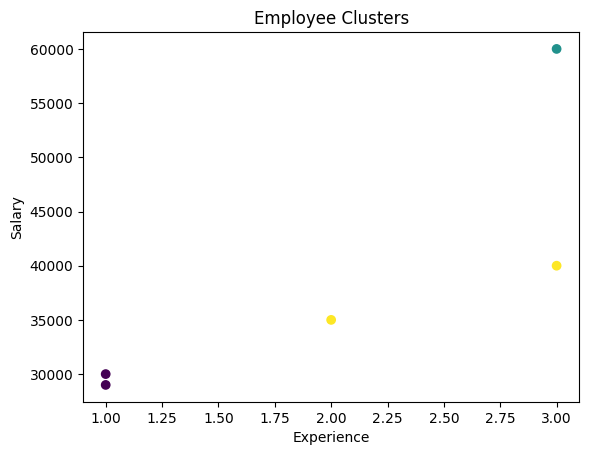

In [ ]:
plt.scatter(
    df["empexp"],
    df["empsal"],
    c=df["Cluster"]
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Employee Clusters")

plt.show()

K-means is a popular unsupervised machine learning algorithm used for clustering data. Its goal is to partition n observations into k clusters, where each observation belongs to the cluster with the nearest mean (centroid). Here's a breakdown of how it works:

Initialization: You first choose the number of clusters, k, you want to identify. Then, k initial centroids are randomly selected from the data points.

Assignment Step: Each data point is assigned to the nearest centroid. The 'nearest' is typically determined by Euclidean distance.

Update Step: The centroids are re-calculated as the mean of all data points assigned to that cluster.

Iteration: Steps 2 and 3 are repeated until the centroids no longer move significantly, or a maximum number of iterations is reached. This indicates that the clusters have stabilized.



Hierarchical clustering is another method for grouping similar data points into clusters. Unlike K-means, which requires you to specify the number of clusters (k) beforehand, hierarchical clustering builds a hierarchy of clusters. There are two main types:

Agglomerative (bottom-up): This is the most common type. It starts with each data point as a single cluster. Then, it iteratively merges the closest pairs of clusters until all data points are in a single cluster or a stopping criterion is met. The 'closeness' between clusters can be defined in various ways (e.g., single linkage, complete linkage, average linkage, Ward's method).

Divisive (top-down): This approach starts with all data points in one large cluster and recursively splits the clusters into smaller ones until each data point is a single cluster or a stopping criterion is met.

The results of hierarchical clustering are often represented by a dendrogram, which is a tree-like diagram that shows the sequence of merges or splits and the similarity levels at which they occurred. You can then 'cut' the dendrogram at a certain height to obtain a desired number of clusters.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform Hierarchical Clustering with n_clusters=3
hc_model = AgglomerativeClustering(n_clusters=3, linkage='ward') # 'ward' minimizes variance within clusters
df['Hierarchical_Cluster'] = hc_model.fit_predict(X)

display(df)

,empid,empname,empage,empsal,empexp,Cluster,Hierarchical_Cluster
0,101,Rahul,23,30000,1,0,2
1,102,Sam,34,29000,1,0,2
2,103,Suji,24,35000,2,2,0
3,104,Saba,22,40000,3,2,0
4,105,Chiru,21,60000,3,1,1


Now, let's visualize the hierarchical clusters. We'll also plot a dendrogram to show the clustering hierarchy.

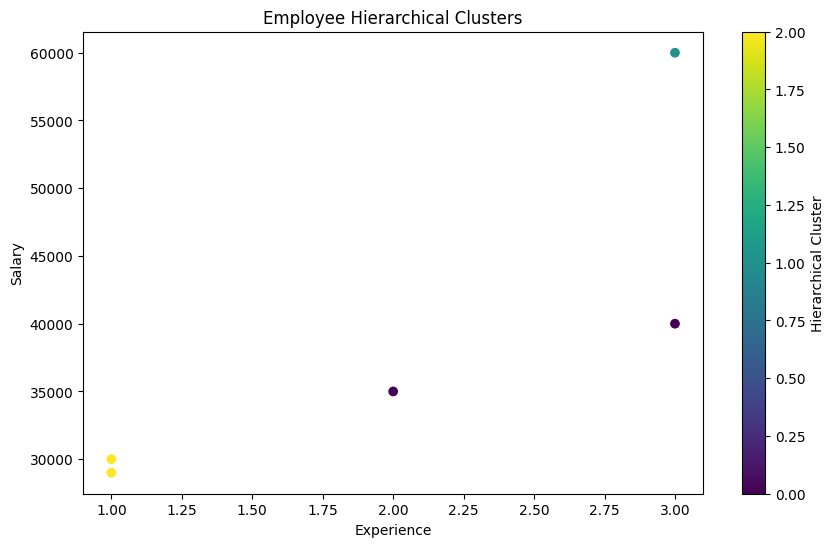

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["empexp"],
    df["empsal"],
    c=df["Hierarchical_Cluster"]
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Employee Hierarchical Clusters")
plt.colorbar(label='Hierarchical Cluster')
plt.show()

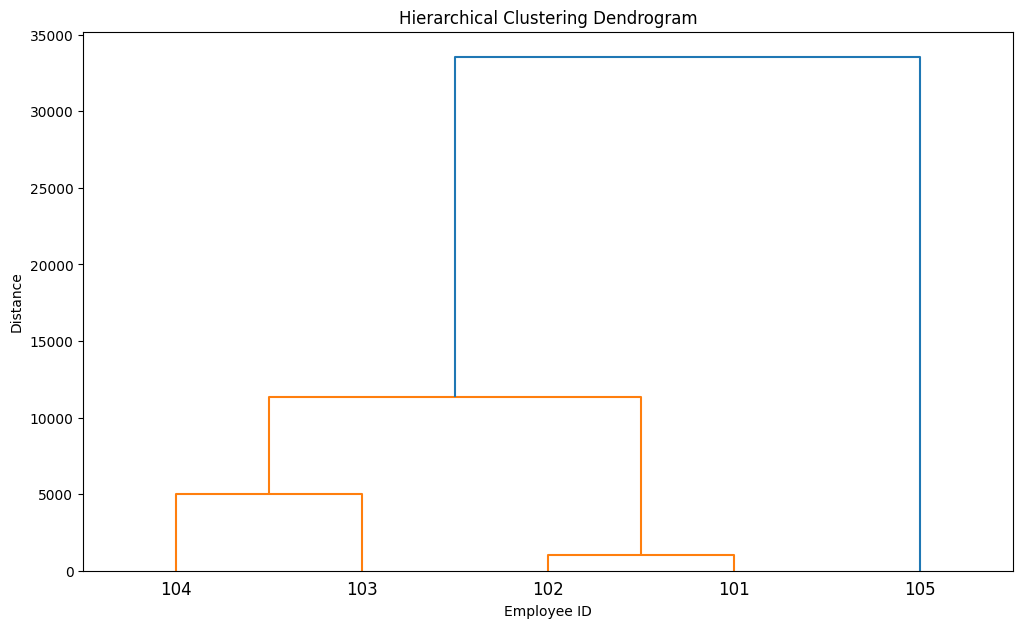

In [ ]:
plt.figure(figsize=(12, 7))
linked = linkage(X, method='ward') # Perform hierarchical clustering
dendrogram(
    linked,
    orientation='top',
    labels=df['empid'].values,
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Employee ID')
plt.ylabel('Distance')
plt.show()

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions. Unlike K-Means, you don't need to specify the number of clusters beforehand.

DBSCAN is particularly good at finding clusters of arbitrary shapes and can identify outliers effectively.

Association Rule Learning finds relationships between items in a dataset.

Example rule:

Bread → Milk

Introduce the Basic Terminology

Itemset -> A collection of items.

Rule -> A relationship

In [ ]:
# Import the pandas library
import pandas as pd

# Create a dictionary where:
# - Keys are column names (items)
# - Values are lists representing whether the item was purchased (1) or not (0)
data = {
    'Bread':   [1, 1, 0, 1, 1],
    'Milk':    [1, 0, 1, 1, 1],
    'Diapers': [0, 1, 1, 1, 1],
    'Beer':    [0, 1, 1, 1, 0],
    'Coke':    [0, 0, 1, 0, 1]
}

# Convert the dictionary into a pandas DataFrame
# Each row represents a transaction
# Each column represents an item
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

   Bread  Milk  Diapers  Beer  Coke
0      1     1        0     0     0
1      1     0        1     1     0
2      0     1        1     1     1
3      1     1        1     1     0
4      1     1        1     0     1


Apriori Algorithm: Apriori Algorithm is a popular algorithm used in Association Rule Learning to discover frequent item combinations in a dataset and generate association rules.

The Apriori algorithm finds:

Frequent itemsets (items that often occur together)

Association rules (relationships between those items)

In [ ]:
# Import the apriori function from mlxtend
# Apriori is used to find frequent itemsets in transactional data
from mlxtend.frequent_patterns import apriori

# Generate frequent itemsets
frequent_itemsets = apriori(
    df,                 # Input DataFrame containing transaction data (0s and 1s)
    min_support=0.4,    # Minimum support threshold (40%)
                         # An itemset must appear in at least 40% of transactions
    use_colnames=True   # Display item names instead of column indices
)

# Print the resulting frequent itemsets
print(frequent_itemsets)

    support                itemsets
0       0.8                 (Bread)
1       0.8                  (Milk)
2       0.8               (Diapers)
3       0.6                  (Beer)
4       0.4                  (Coke)
5       0.6           (Bread, Milk)
6       0.6        (Bread, Diapers)
7       0.4           (Bread, Beer)
8       0.6         (Diapers, Milk)
9       0.4            (Beer, Milk)
10      0.4            (Coke, Milk)
11      0.6         (Beer, Diapers)
12      0.4         (Coke, Diapers)
13      0.4  (Bread, Diapers, Milk)
14      0.4  (Bread, Beer, Diapers)
15      0.4   (Beer, Diapers, Milk)
16      0.4   (Coke, Diapers, Milk)


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

In [ ]:
# Import the association_rules function
# This function generates association rules from the frequent itemsets
from mlxtend.frequent_patterns import association_rules

# Generate association rules
rules = association_rules(
    frequent_itemsets,     # Frequent itemsets obtained from the Apriori algorithm
    metric="confidence",   # Use confidence as the evaluation metric
    min_threshold=0.7      # Only keep rules with confidence >= 70%
)

# Display selected columns from the generated rules
print(
    rules[
        [
            'antecedents',  # Items on the left-hand side (IF part)
            'consequents',  # Items on the right-hand side (THEN part)
            'support',      # Frequency of the entire rule in the dataset
            'confidence',   # Probability of consequent given antecedent
            'lift'          # Strength of the rule compared to random occurrence
        ]
    ]
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

        antecedents      consequents  support  confidence      lift
0           (Bread)           (Milk)      0.6        0.75  0.937500
1            (Milk)          (Bread)      0.6        0.75  0.937500
2           (Bread)        (Diapers)      0.6        0.75  0.937500
3         (Diapers)          (Bread)      0.6        0.75  0.937500
4         (Diapers)           (Milk)      0.6        0.75  0.937500
5            (Milk)        (Diapers)      0.6        0.75  0.937500
6            (Coke)           (Milk)      0.4        1.00  1.250000
7            (Beer)        (Diapers)      0.6        1.00  1.250000
8         (Diapers)           (Beer)      0.6        0.75  1.250000
9            (Coke)        (Diapers)      0.4        1.00  1.250000
10    (Bread, Beer)        (Diapers)      0.4        1.00  1.250000
11     (Beer, Milk)        (Diapers)      0.4        1.00  1.250000
12  (Coke, Diapers)           (Milk)      0.4        1.00  1.250000
13     (Coke, Milk)        (Diapers)      0.4   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

FP-Growth (Frequent Pattern Growth) is an algorithm used in association rule mining. It is an alternative to the Apriori algorithm for finding frequent itemsets in a transactional database. Its main advantage is that it does not generate candidate itemsets, making it more efficient, especially for large datasets.

Here's a simplified overview of how it works:

Construct an FP-Tree: It scans the database once to build a data structure called an FP-Tree (Frequent Pattern Tree). This tree stores the frequent itemsets in a compressed format.

Mine the FP-Tree: It then recursively mines this tree to find all frequent itemsets without generating candidate itemsets.

In simpler terms, imagine you're looking for common combinations of items bought together. FP-Growth efficiently identifies these combinations by building a special tree that represents the buying patterns, and then it extracts the frequent patterns directly from this tree.